Code: **Power spectrum calculation for three-field model**  
Date: March 2026  
Written by: Mehdi Nasrolahzadeh  

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [2]:
# constants:

V0 = 13.6e-10
Mp = 1
mchi = np.sqrt(V0 / 500)
mpsi = np.sqrt(V0 / 80000)
phi0 = np.sqrt(6) * Mp
b0 = 7.6 / Mp
y0 = 7.6 / Mp
p0 = 0
mp = 2.435515 * 1e18
mpc = (6.394970897 * 1e-39) / mp   # Mpc^{-1} =  2.63 * 1e-57 Mp (arXiv: 2110.12251)
k0 = 0.05 * mpc

In [3]:
def power(a,b):     # a ^ b
    s = 1
    for i in range(b):
        s *= a
    return s

In [4]:
# potential V(phi,chi,psi):

def V(phi,chi,psi):
    return V0 * power(phi,2) / (power(phi0,2) + power(phi,2)) + 0.5 * power(mchi,2) * power(chi,2) + 0.5 * power(mpsi,2) * power(psi,2)

# derivates of the potential:


def V_phi(phi,chi,psi):
   h = 1e-5
   return (V(phi + h,chi,psi) - V(phi - h,chi,psi)) / (2 * h)

def V_chi(phi,chi,psi):
   h = 1e-5
   return (V(phi,chi + h,psi) - V(phi,chi - h,psi)) / (2 * h)

def V_psi(phi,chi,psi):
   h = 1e-5
   return (V(phi,chi,psi + h) - V(phi,chi,psi - h)) / (2 * h)

def V_phiphi(phi,chi,psi):
   h = 1e-5
   return (V_phi(phi + h , chi,psi) - V_phi(phi - h , chi,psi)) / (2 * h)

def V_chichi(phi,chi,psi):
   h = 1e-5
   return (V_chi(phi,chi + h,psi) - V_chi(phi,chi - h,psi)) / (2 * h)

def V_psipsi(phi,chi,psi):
   h = 1e-5
   return (V_psi(phi,chi,psi + h) - V_psi(phi,chi,psi - h)) / (2 * h)

def V_phichi(phi,chi,psi):
   h = 1e-5
   return (V_phi(phi,chi + h,psi) - V_phi(phi,chi - h,psi)) / (2 * h)

def V_phipsi(phi,chi,psi):
   h = 1e-5
   return (V_phi(phi,chi,psi + h) - V_phi(phi,chi,psi - h)) / (2 * h)

def V_chipsi(phi,chi,psi):
   h = 1e-5
   return (V_chi(phi,chi,psi + h) - V_chi(phi,chi,psi - h)) / (2 * h)

In [5]:
# noncanonical coefficients:

def b(phi):
    return b0 * phi
def y(phi):
    return y0 * phi
def p(chi):
    return p0 * chi

# derivatives:

def b_phi(phi):
    h = 1e-5
    return (b(phi + h) - b(phi - h)) / (2 * h)
def y_phi(phi):
    h = 1e-5
    return (y(phi + h) - y(phi - h)) / (2 * h)
def p_chi(chi):
    h = 1e-5
    return (p(chi + h) - p(chi - h)) / (2 * h)

# second derivatives for perturbations:

def b_phiphi(phi):
    h = 1e-5
    return (b_phi(phi + h) - b_phi(phi - h)) / (2 * h)
def y_phiphi(phi):
    h = 1e-5
    return (y_phi(phi + h) - y_phi(phi - h)) / (2 * h)
def p_chichi(chi):
    h = 1e-5
    return (p_chi(chi + h) - p_chi(chi - h)) / (2 * h)

In [6]:
def G_ab(phi,chi):     # field-space metric
    return np.array([[1,0,0],[0, np.exp(2 * b(phi)) ,0],[0,0, np.exp(2 * y(phi) + 2 * p(chi))]])

<center>
  <span style="color: #ff5722; font-weight: bold; font-size: 1.2em;">
    Background evolution
  </span>
</center>

In [8]:
def H(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN):
    G = G_ab(phi,chi)
    value = np.sqrt((2 * V(phi,chi,psi)) / (6 * power(Mp,2) - G[0][0] * power(dphi_dN,2) - G[1][1] * power(dchi_dN ,2) - G[2][2] * power(dpsi_dN ,2)))
    return value

def dH_dN(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN):
    G = G_ab(phi,chi)
    Hub = H(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    value = - 0.5 * (1 / power(Mp,2)) * Hub * (G[0][0] * power(dphi_dN ,2) + G[1][1] * power(dchi_dN,2) + G[2][2] * power(dpsi_dN,2))
    return value

def numeps(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN):
    Hub = H(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    dH = dH_dN(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    return - dH / Hub

In [9]:
# Background equations of motion:

def background(N,y):
    phi, dphi_dN, chi, dchi_dN, psi, dpsi_dN = y
    H_val = H(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    eps = numeps(phi,chi,psi,dphi_dN,dchi_dN,dpsi_dN)
    G = G_ab(phi,chi)
    d2phi_dN2 = -(3 - eps) * dphi_dN + b_phi(phi) * G[1][1] * power(dchi_dN,2) + y_phi(phi) * G[2][2] * power(dpsi_dN,2) - V_phi(phi,chi,psi) / power(H_val,2)
    d2chi_dN2 = -(3 + 2 * b_phi(phi) * dphi_dN - eps) * dchi_dN + p_chi(chi) * (G[2][2] / G[1][1]) * power(dpsi_dN,2) - (1 / G[1][1]) * V_chi(phi,chi,psi) / power(H_val,2)
    d2psi_dN2 = -(3 + 2 * b_phi(phi) * dphi_dN + 2 * p_chi(chi) * dchi_dN - eps) * dpsi_dN - (1 / G[2][2]) * V_psi(phi,chi,psi) / power(H_val,2)
    return np.array([dphi_dN, d2phi_dN2, dchi_dN, d2chi_dN2, dpsi_dN, d2psi_dN2])

In [10]:
# Initial condition + Integration:

phi_i = 7
chi_i = 7.31
psi_i = 7.31
phi_dot_i = 0#- V_phi(phi_i,chi_i,psi_i) / V(phi_i,chi_i,psi_i)
chi_dot_i = 0#- V_chi(phi_i,chi_i,psi_i) / V(phi_i,chi_i,psi_i)
psi_dot_i = 0#- V_psi(phi_i,chi_i,psi_i) / V(phi_i,chi_i,psi_i)
Inc = np.array([phi_i, phi_dot_i, chi_i, chi_dot_i, psi_i, psi_dot_i])
 
sample_size = 10000 # to pass the stiffness
NEnd = 99.81 # estimated end for inflation

NE = np.linspace(0 , NEnd, sample_size)
sol_background = solve_ivp(background, [0 , NEnd], Inc,t_eval=NE,
                          method='LSODA', rtol=1e-6, atol=1e-8)
N_vals = sol_background.t
phi_vals = sol_background.y[0]
dphidN = sol_background.y[1]
chi_vals = sol_background.y[2]
dchidN = sol_background.y[3]
psi_vals = sol_background.y[4]
dpsidN = sol_background.y[5]

Hubble_vals = [H(phi_vals[i],chi_vals[i],psi_vals[i],dphidN[i],dchidN[i],dpsidN[i]) for i in range(len(N_vals))]
epsilon = np.array([-(1 / H(phi_vals[i],chi_vals[i],psi_vals[i],dphidN[i],dchidN[i],dpsidN[i])) * dH_dN(phi_vals[i],chi_vals[i],psi_vals[i],dphidN[i],dchidN[i],dpsidN[i]) for i in range(len(N_vals))])
Eta = np.gradient(epsilon,N_vals) / epsilon

C:\Users\Mehdi\AppData\Local\Temp\ipykernel_7848\3705451276.py:27: RuntimeWarning: divide by zero encountered in divide
  Eta = np.gradient(epsilon,N_vals) / epsilon


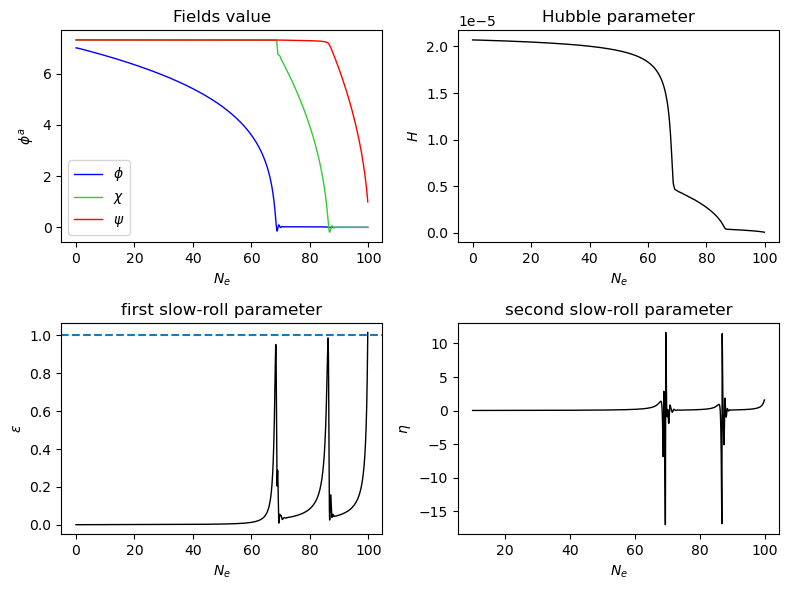

In [11]:
fig = plt.figure(figsize=(8, 6))

ax1 = fig.add_subplot(2, 2, 1) 
ax1.plot(N_vals, phi_vals, label=r'$\phi$', color='blue',linewidth=1)
ax1.plot(N_vals, chi_vals, label=r'$\chi$', color='limegreen',linewidth=1)
ax1.plot(N_vals, psi_vals, label=r'$\psi$', color='r',linewidth=1)
ax1.set_xlabel(r"$N_e$")
ax1.set_ylabel(r'$\phi^a$')
plt.legend()
ax1.set_title('Fields value')

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(N_vals,Hubble_vals,color='black',linewidth=1)
ax2.set_xlabel(r"$N_e$")
ax2.set_ylabel(r"$H$")
ax2.set_title('Hubble parameter')

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(N_vals,epsilon, color='black',linewidth=1)
ax3.axhline(1,linestyle='--')
ax3.set_xlabel(r"$N_e$")
ax3.set_ylabel(r"$\epsilon$")
ax3.set_title('first slow-roll parameter')

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(N_vals[1000:],Eta[1000:],color='black',linewidth=1)
ax4.set_xlabel(r"$N_e$")
ax4.set_ylabel(r"$\eta$")
ax4.set_title('second slow-roll parameter')

plt.tight_layout()
#plt.savefig('3fields_background.pdf',format = 'pdf' , dpi = 700)
plt.show()

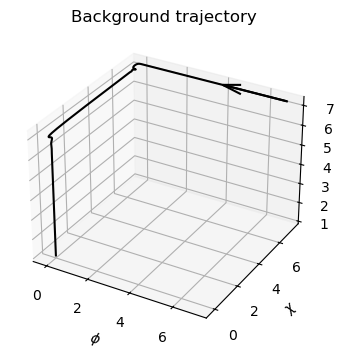

In [12]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')
ax.plot(phi_vals, chi_vals, psi_vals,color='black')
ax.quiver(phi_vals[0], chi_vals[0], psi_vals[0],phi_vals[1]-phi_vals[0], chi_vals[1]-chi_vals[0], psi_vals[1]-psi_vals[0],
    length=3.0, normalize=True, color='black', arrow_length_ratio=.3)
ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$\chi$')
ax.set_zlabel(r'$\psi$')
ax.set_title('Background trajectory')
plt.show()

In [13]:
end_inf = np.argmin(np.abs(1 - epsilon))
N_end = N_vals[end_inf]
N_pivot = N_end - 50 
pivot_idx = np.argmin(np.abs(N_pivot - N_vals))
a0 = (k0 / Hubble_vals[pivot_idx]) * np.exp(-N_vals[pivot_idx])    # normalize a(N) so that k∗ = 0.05 crosses the Hubble radius N∗ = 50 e-folds before the end of inflation.
a_vals = a0 * np.exp(N_vals)
K = a_vals * Hubble_vals  # Comoving Hubble scale

In [14]:
print('N_end =',N_vals[np.argmin(np.abs(1 - epsilon))])
print('ϵ =', epsilon[np.argmin(np.abs(1 - epsilon))])

N_end = 99.80001800180018
ϵ = 0.9997310883379056


<center>
  <span style="color: #ff5722; font-weight: bold; font-size: 1.2em;">
    Turning parameters (TNB method) 
  </span>
</center>

In [15]:
def sigma_dot(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    dphi = dphidN[idx]
    chi = chi_vals[idx]
    dchi = dchidN[idx]
    psi = psi_vals[idx]
    dpsi = dpsidN[idx]
    Hub = H(phi,chi,psi,dphi,dchi,dpsi)
    G = G_ab(phi,chi)
    val = power(Hub,2) * (dphi ** 2 + G[1][1] * dchi ** 2 + G[2][2] * dpsi ** 2)
    return np.sqrt(val) 

In [16]:
sigma_vals = [sigma_dot(ne) for ne in N_vals]

In [99]:
# tangent vector to the background trajectory:

T1 , T2 , T3 = [] , [] , []
for i in range(len(N_vals)):
    T1.append(Hubble_vals[i] * dphidN[i] / sigma_vals[i])
    T2.append(Hubble_vals[i] * dchidN[i] / sigma_vals[i])
    T3.append(Hubble_vals[i] * dpsidN[i] / sigma_vals[i])
T1 = np.array(T1)
T2 = np.array(T2)
T3 = np.array(T3)

C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\111139596.py:5: RuntimeWarning: invalid value encountered in scalar divide
  T1.append(Hubble_vals[i] * dphidN[i] / sigma_vals[i])
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\111139596.py:6: RuntimeWarning: invalid value encountered in scalar divide
  T2.append(Hubble_vals[i] * dchidN[i] / sigma_vals[i])
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\111139596.py:7: RuntimeWarning: invalid value encountered in scalar divide
  T3.append(Hubble_vals[i] * dpsidN[i] / sigma_vals[i])


In [100]:
def turning(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    dphi = dphidN[idx]
    chi = chi_vals[idx]
    dchi = dchidN[idx]
    psi = psi_vals[idx]
    dpsi = dpsidN[idx]
    Hub = H(phi,chi,psi,dphi,dchi,dpsi)
    G = G_ab(phi,chi)
    ddotphi = -3 * Hub ** 2 * dphi + b_phi(phi) * G[1][1] * Hub ** 2 * dchi ** 2 + y_phi(phi) * G[2][2] * Hub ** 2 * dpsi ** 2 - V_phi(phi,chi,psi)
    ddotchi = - (3 + 2 * b_phi(phi) * dphi) * power(Hub,2) * dchi + p_chi(chi) * (G[2][2] / G[1][1]) * power(Hub * dpsi,2) - V_chi(phi,chi,psi) / G[1][1]
    ddotpsi = - (3 + 2 * y_phi(phi) * dphi + 2 * p_chi(chi) * dchi) * power(Hub,2) * dpsi - V_psi(phi,chi,psi) / G[2][2]
    ddotsigma = (Hub * ddotphi * dphi + G[1][1] * Hub * ddotchi * dchi + G[2][2] * Hub * ddotpsi * dpsi + b_phi(phi) * G[1][1] * power(Hub,3) * power(dchi,2) * dphi + y_phi(phi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dphi + p_chi(chi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dchi) / sigma_dot(Ne)
    Dtphi = - 3 * power(Hub,2) * dphi - V_phi(phi,chi,psi) / G[0][0]
    Dtchi = - 3 * power(Hub,2) * dchi - V_chi(phi,chi,psi) / G[1][1]
    Dtpsi = - 3 * power(Hub,2) * dpsi - V_psi(phi,chi,psi) / G[2][2]
    DtT1 = Dtphi / sigma_dot(Ne) - Hub * dphi * ddotsigma / power(sigma_dot(Ne),2)
    DtT2 = Dtchi / sigma_dot(Ne) - Hub * dchi * ddotsigma / power(sigma_dot(Ne),2)
    DtT3 = Dtpsi / sigma_dot(Ne) - Hub * dpsi * ddotsigma / power(sigma_dot(Ne),2)
    val = power(DtT1,2) + G[1][1] * power(DtT2,2) + G[2][2] * power(DtT3,2)
    return np.sqrt(val)        

In [101]:
OMEGA = []
for i in range(len(N_vals)):
    OMEGA.append(turning(N_vals[i]))

OMEGA = np.array(OMEGA)

C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\4089862413.py:14: RuntimeWarning: invalid value encountered in scalar divide
  ddotsigma = (Hub * ddotphi * dphi + G[1][1] * Hub * ddotchi * dchi + G[2][2] * Hub * ddotpsi * dpsi + b_phi(phi) * G[1][1] * power(Hub,3) * power(dchi,2) * dphi + y_phi(phi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dphi + p_chi(chi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dchi) / sigma_dot(Ne)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\4089862413.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  DtT1 = Dtphi / sigma_dot(Ne) - Hub * dphi * ddotsigma / power(sigma_dot(Ne),2)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\4089862413.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  DtT2 = Dtchi / sigma_dot(Ne) - Hub * dchi * ddotsigma / power(sigma_dot(Ne),2)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\4089862413.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  DtT3 = Dtpsi / sigma_do

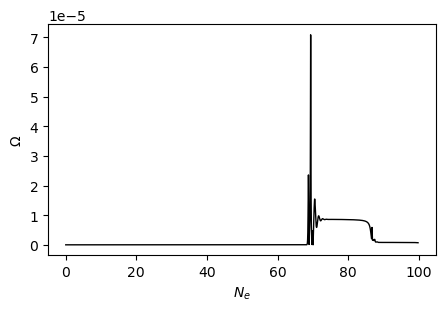

In [102]:
plt.figure(figsize=(5,3))
plt.plot(N_vals,OMEGA,color='black',linewidth=1)
plt.xlabel(r"$N_e$")
plt.ylabel(r"$\Omega$")
plt.show()

In [147]:
def Normal(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    dphi = dphidN[idx]
    chi = chi_vals[idx]
    dchi = dchidN[idx]
    psi = psi_vals[idx]
    dpsi = dpsidN[idx]
    Hub = H(phi,chi,psi,dphi,dchi,dpsi)
    G = G_ab(phi,chi)
    ddotphi = -3 * Hub ** 2 * dphi + b_phi(phi) * G[1][1] * Hub ** 2 * dchi ** 2 + y_phi(phi) * G[2][2] * Hub ** 2 * dpsi ** 2 - V_phi(phi,chi,psi)
    ddotchi = - (3 + 2 * b_phi(phi) * dphi) * power(Hub,2) * dchi + p_chi(chi) * (G[2][2] / G[1][1]) * power(Hub * dpsi,2) - V_chi(phi,chi,psi) / G[1][1]
    ddotpsi = - (3 + 2 * y_phi(phi) * dphi + 2 * p_chi(chi) * dchi) * power(Hub,2) * dpsi - V_psi(phi,chi,psi) / G[2][2]
    ddotsigma = (Hub * ddotphi * dphi + G[1][1] * Hub * ddotchi * dchi + G[2][2] * Hub * ddotpsi * dpsi + b_phi(phi) * G[1][1] * power(Hub,3) * power(dchi,2) * dphi + y_phi(phi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dphi + p_chi(chi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dchi) / sigma_dot(Ne)
    Dtphi = - 3 * power(Hub,2) * dphi - V_phi(phi,chi,psi) / G[0][0]
    Dtchi = - 3 * power(Hub,2) * dchi - V_chi(phi,chi,psi) / G[1][1]
    Dtpsi = - 3 * power(Hub,2) * dpsi - V_psi(phi,chi,psi) / G[2][2]
    DtT1 = Dtphi / sigma_dot(Ne) - Hub * dphi * ddotsigma / power(sigma_dot(Ne),2)
    DtT2 = Dtchi / sigma_dot(Ne) - Hub * dchi * ddotsigma / power(sigma_dot(Ne),2)
    DtT3 = Dtpsi / sigma_dot(Ne) - Hub * dpsi * ddotsigma / power(sigma_dot(Ne),2)
    val = power(DtT1,2) + G[1][1] * power(DtT2,2) + G[2][2] * power(DtT3,2)
    Omega = np.sqrt(val)
    if Omega < 1e-6:
        Omega = 1e-6
    N1 = DtT1 / Omega
    N2 = DtT2 / Omega
    N3 = DtT3 / Omega
    return N1 , N2 , N3

In [148]:
N1 , N2 , N3 = [] , [] , []
for i in range(len(N_vals)):
    N1.append(Normal(N_vals[i])[0])
    N2.append(Normal(N_vals[i])[1])
    N3.append(Normal(N_vals[i])[2])
N1 = np.array(N1)
N2 = np.array(N2)
N3 = np.array(N3)

C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\2062052341.py:14: RuntimeWarning: invalid value encountered in scalar divide
  ddotsigma = (Hub * ddotphi * dphi + G[1][1] * Hub * ddotchi * dchi + G[2][2] * Hub * ddotpsi * dpsi + b_phi(phi) * G[1][1] * power(Hub,3) * power(dchi,2) * dphi + y_phi(phi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dphi + p_chi(chi) * G[2][2] * power(Hub,3) * power(dpsi,2) * dchi) / sigma_dot(Ne)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\2062052341.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  DtT1 = Dtphi / sigma_dot(Ne) - Hub * dphi * ddotsigma / power(sigma_dot(Ne),2)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\2062052341.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  DtT2 = Dtchi / sigma_dot(Ne) - Hub * dchi * ddotsigma / power(sigma_dot(Ne),2)
C:\Users\Mehdi\AppData\Local\Temp\ipykernel_21112\2062052341.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  DtT3 = Dtpsi / sigma_do

In [141]:
def Binormal(Ne):
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    psi = psi_vals[idx]
    chi = chi_vals[idx]
    G = G_ab(phi,chi)
    detG = G[1][1] * G[2][2]
    t1 = G[0][0] * T1[idx]
    t2 = G[1][1] * T2[idx]
    t3 = G[2][2] * T3[idx]
    n1 = G[0][0] * N1[idx]
    n2 = G[1][1] * N2[idx]
    n3 = G[2][2] * N3[idx]
    B1 = (t2 * n3 - t3 * n2) / np.sqrt(detG)
    B2 = (t3 * n1 - t1 * n3) / np.sqrt(detG)
    B3 = (t1 * n2 - t2 * n1) / np.sqrt(detG)
    return B1 , B2 , B3    

In [149]:
B1 , B2 , B3 = [] , [] , []
for i in range(len(N_vals)):
    B1.append(Binormal(N_vals[i])[0])
    B2.append(Binormal(N_vals[i])[1])
    B3.append(Binormal(N_vals[i])[2])
B1 = np.array(B1)
B2 = np.array(B2)
B3 = np.array(B3)

In [150]:
def torsion(Ne): 
    idx = np.argmin(np.abs(Ne - N_vals))
    phi = phi_vals[idx]
    dphi = dphidN[idx]
    psi = psi_vals[idx]
    dpsi = dpsidN[idx]
    chi = chi_vals[idx]
    dchi = dchidN[idx]
    Hub = H(phi,chi,psi,dphi,dchi,dpsi)
    G = G_ab(phi,chi)
    Γ122 = -b_phi(phi) * G[1][1] 
    Γ133 = -y_phi(phi) * G[2][2]
    Γ112 = b_phi(phi)
    Γ121 = Γ112
    Γ233 = -p_chi(chi) * G[2][2] / G[1][1]
    Γ313 = y_phi(phi)
    Γ331 = Γ313
    Γ323 = p_chi(chi)
    Γ332 = Γ323
    B1dot = Hub * np.gradient(B1,N_vals)[idx]
    B2dot = Hub * np.gradient(B2,N_vals)[idx]
    B3dot = Hub * np.gradient(B3,N_vals)[idx]
    DtB1 = B1dot + Γ122 * B2[idx] * Hub * dchi + Γ133 * B3[idx] * Hub * dpsi + Γ112 * B2[idx] * Hub * dphi + Γ121 * B1[idx] * Hub * dchi
    DtB2 = B2dot + Γ233 * B3[idx] * Hub * dpsi
    DtB3 = B3dot + Γ313 * B3[idx] * Hub * dphi + Γ331 * B1[idx] * Hub * dpsi + Γ323 * B3[idx] * Hub * dchi + Γ332 * B2[idx] * Hub * dpsi
    n1 = G[0][0] * N1[idx]
    n2 = G[1][1] * N2[idx]
    n3 = G[2][2] * N3[idx]
    torz = - n1 * DtB1 - n2 * DtB2 - n3 * DtB3
    return torz

In [151]:
Bidx = np.argmin(np.abs(30-N_vals))
Eidx = np.argmin(np.abs(46.7-N_vals))
Didx = np.argmin(np.abs(67-N_vals))
Fidx = np.argmin(np.abs(81-N_vals))
Gidx = np.argmin(np.abs(95-N_vals))

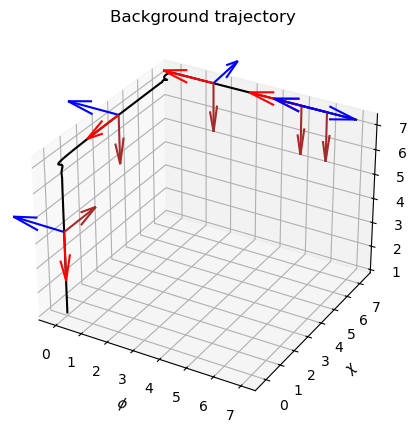

In [158]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot(phi_vals, chi_vals, psi_vals,color='black')
ax.quiver(phi_vals[0], chi_vals[0], psi_vals[0],T1[0], T2[0], T3[0],
    length=2.0, normalize=True, color='red', arrow_length_ratio=.5)
ax.quiver(phi_vals[0], chi_vals[0], psi_vals[0],N1[0], N2[0], N3[0],
    length=2.0, normalize=True, color='blue', arrow_length_ratio=.5)
ax.quiver(phi_vals[0], chi_vals[0], psi_vals[0],B1[0], B2[0], B3[0],
    length=2.0, normalize=True, color='brown', arrow_length_ratio=.5)

ax.quiver(phi_vals[Eidx], chi_vals[Eidx], psi_vals[Eidx],T1[Eidx], T2[Eidx], T3[Eidx],
    length=2.0, normalize=True, color='red', arrow_length_ratio=.5)
ax.quiver(phi_vals[Eidx], chi_vals[Eidx], psi_vals[Eidx],N1[Eidx], N2[Eidx], N3[Eidx],
    length=2.0, normalize=True, color='blue', arrow_length_ratio=.5)
ax.quiver(phi_vals[Eidx], chi_vals[Eidx], psi_vals[Eidx],B1[Eidx], B2[Eidx], B3[Eidx],
    length=2.0, normalize=True, color='brown', arrow_length_ratio=.5)

ax.quiver(phi_vals[Bidx], chi_vals[Bidx], psi_vals[Bidx],T1[Bidx], T2[Bidx], T3[Bidx],
    length=2.0, normalize=True, color='red', arrow_length_ratio=.5)
ax.quiver(phi_vals[Bidx], chi_vals[Bidx], psi_vals[Bidx],N1[Bidx], N2[Bidx], N3[Bidx],
    length=2.0, normalize=True, color='blue', arrow_length_ratio=.5)
ax.quiver(phi_vals[Bidx], chi_vals[Bidx], psi_vals[Bidx],B1[Bidx], B2[Bidx], B3[Bidx],
    length=2.0, normalize=True, color='brown', arrow_length_ratio=.5)

ax.quiver(phi_vals[Didx], chi_vals[Didx], psi_vals[Didx],T1[Didx], T2[Didx], T3[Didx],
    length=2.0, normalize=True, color='red', arrow_length_ratio=.5)
ax.quiver(phi_vals[Didx], chi_vals[Didx], psi_vals[Didx],N1[Didx], N2[Didx], N3[Didx],
    length=2.0, normalize=True, color='blue', arrow_length_ratio=.5)
ax.quiver(phi_vals[Didx], chi_vals[Didx], psi_vals[Didx],B1[Didx], B2[Didx], B3[Didx],
    length=2.0, normalize=True, color='brown', arrow_length_ratio=.5)

ax.quiver(phi_vals[Fidx], chi_vals[Fidx], psi_vals[Fidx],T1[Fidx], T2[Fidx], T3[Fidx],
    length=2.0, normalize=True, color='red', arrow_length_ratio=.5)
ax.quiver(phi_vals[Fidx], chi_vals[Fidx], psi_vals[Fidx],N1[Fidx], N2[Fidx], N3[Fidx],
    length=2.0, normalize=True, color='blue', arrow_length_ratio=.5)
ax.quiver(phi_vals[Fidx], chi_vals[Fidx], psi_vals[Fidx],B1[Fidx], B2[Fidx], B3[Fidx],
    length=2.0, normalize=True, color='brown', arrow_length_ratio=.5)

ax.quiver(phi_vals[Gidx], chi_vals[Gidx], psi_vals[Gidx],T1[Gidx], T2[Gidx], T3[Gidx],
    length=2.0, normalize=True, color='red', arrow_length_ratio=.5)
ax.quiver(phi_vals[Gidx], chi_vals[Gidx], psi_vals[Gidx],N1[Gidx], N2[Gidx], N3[Gidx],
    length=2.0, normalize=True, color='blue', arrow_length_ratio=.5)
ax.quiver(phi_vals[Gidx], chi_vals[Gidx], psi_vals[Gidx],B1[Gidx], B2[Gidx], B3[Gidx],
    length=2.0, normalize=True, color='brown', arrow_length_ratio=.5)

ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$\chi$')
ax.set_zlabel(r'$\psi$')
ax.set_title('Background trajectory')
plt.show()

In [152]:
TORSION = []
for i in range(len(N_vals)):
    TORSION.append(torsion(N_vals[i]))

TORSION = np.array(TORSION)

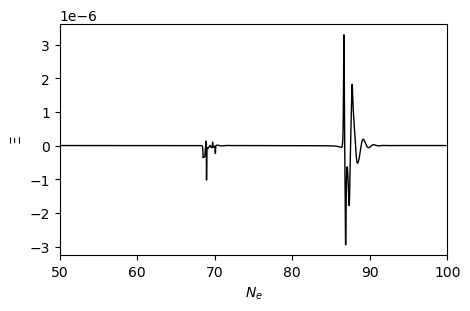

In [153]:
plt.figure(figsize=(5,3))
plt.plot(N_vals,TORSION,color='black',linewidth=1)
plt.xlabel(r"$N_e$")
plt.ylabel(r"$\Xi$")
plt.xlim(50,100)
plt.show()

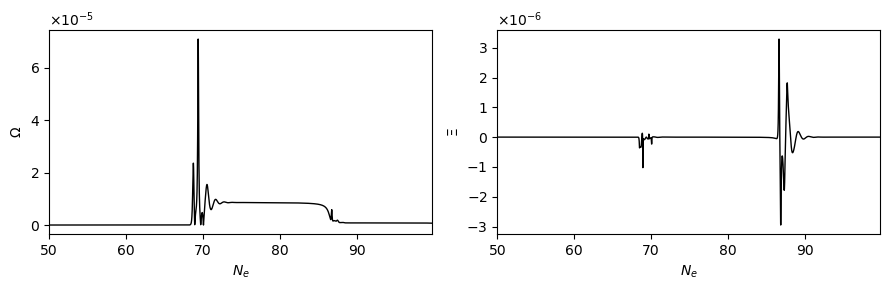

In [ ]:
#import matplotlib.pyplot as plt
#from matplotlib.ticker import ScalarFormatter
fig = plt.figure(figsize=(9, 3))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(N_vals, OMEGA, color='black', linewidth=1)
ax1.set_xlabel(r"$N_e$")
ax1.set_ylabel(r"$\Omega$")
ax1.set_xlim(50, 99.81)
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2)) 
ax1.yaxis.set_major_formatter(formatter)

ax2 = fig.add_subplot(1,2,2)
ax2.plot(N_vals, TORSION, color='black', linewidth=1)
ax2.set_xlabel(r"$N_e$")
ax2.set_ylabel(r"$\Xi$")
ax2.set_xlim(50, 99.81)
formatter2 = ScalarFormatter(useMathText=True)
formatter2.set_scientific(True)
formatter2.set_powerlimits((-2, 2))
ax2.yaxis.set_major_formatter(formatter2)

plt.tight_layout()
#plt.savefig('3F_TT_B.pdf',format = 'pdf' , dpi = 700)
plt.show()


<center>
  <span style="color: #ff5722; font-weight: bold; font-size: 1.2em;">
    Perturbation 
  </span>
</center>

In [17]:
deltaN = 3    # this value is numerically stable in 3-field system

def N_subhorizon(k):
    exit_idx = np.argmin(np.abs(k - K))
    N_init = N_vals[exit_idx] - deltaN
    N_init_idx = np.argmin(np.abs(N_init - N_vals))
    if N_init_idx >= len(N_vals) - 1:
        return np.nan
    else:
        return N_vals[N_init_idx]

In [75]:
def BD_Inc1(k):
    N_init = N_subhorizon(k)
    idx = np.argmin(np.abs(N_vals - N_init))
    a , Hub = a_vals[idx] , Hubble_vals[idx]
    aH , eps , phi , chi, psi , phi_p , chi_p, psi_p = K[idx] , epsilon[idx] , phi_vals[idx] , chi_vals[idx], psi_vals[idx] , dphidN[idx] , dchidN[idx], dpsidN[idx]
    G = G_ab(phi,chi)
    BD_state = 1 / (a * np.sqrt(2 * k))
    dBD_dtau = -BD_state * (1j * k + aH)
    dBD_dN = dBD_dtau / aH
    inc1 = BD_state
    dinc1 = dBD_dN
    inc2 , dinc2 = 0 , 0
    inc3 , dinc3 = 0 , 0
    Phi = (phi_p * dinc1 + G[1][1] * chi_p * dinc2 + G[2][2] * psi_p * dinc3 + (3 * phi_p + b_phi(phi) * G[1][1] * chi_p ** 2 + y_phi(phi) * G[2][2] * psi_p ** 2 + V_phi(phi,chi,psi) / Hub ** 2) * inc1 + (3 * G[1][1] * chi_p + p_chi(chi) * G[2][2] * psi_p ** 2 + V_chi(phi,chi,psi) / Hub ** 2) * inc2 + (3 * G[2][2] * psi_p + V_psi(phi,chi,psi) / Hub ** 2) * inc3) / (2 * power(Mp,2) *(eps - k ** 2 / aH ** 2))
    Phi_p = - Phi + (phi_p * inc1 + G[1][1] * chi_p * inc2 + G[2][2] * psi_p * inc3) / (2 * power(Mp,2))
    return [inc1 , inc2 , inc3 , dinc1 , dinc2 , dinc3 , Phi , Phi_p]

def BD_Inc2(k):
    N_init = N_subhorizon(k)
    idx = np.argmin(np.abs(N_vals - N_init))
    a , Hub = a_vals[idx] , Hubble_vals[idx]
    aH , eps , phi , chi, psi , phi_p , chi_p, psi_p = K[idx] , epsilon[idx] , phi_vals[idx] , chi_vals[idx], psi_vals[idx] , dphidN[idx] , dchidN[idx], dpsidN[idx]
    G = G_ab(phi,chi)
    BD_state = 1 / (a * np.sqrt(2 * k))
    dBD_dtau = -BD_state * (1j * k + aH)
    dBD_dN = dBD_dtau / aH
    inc1 , dinc1 = 0 , 0
    inc2 = BD_state / np.sqrt(G[1][1])
    dinc2 = (dBD_dtau - b_phi(phi) * phi_p * BD_state * aH) / (aH * np.sqrt(G[1][1]))
    inc3 , dinc3 = 0 , 0
    Phi = (phi_p * dinc1 + G[1][1] * chi_p * dinc2 + G[2][2] * psi_p * dinc3 + (3 * phi_p + b_phi(phi) * G[1][1] * chi_p ** 2 + y_phi(phi) * G[2][2] * psi_p ** 2 + V_phi(phi,chi,psi) / Hub ** 2) * inc1 + (3 * G[1][1] * chi_p + p_chi(chi) * G[2][2] * psi_p ** 2 + V_chi(phi,chi,psi) / Hub ** 2) * inc2 + (3 * G[2][2] * psi_p + V_psi(phi,chi,psi) / Hub ** 2) * inc3) / (2 * power(Mp,2) *(eps - k ** 2 / aH ** 2))
    Phi_p = - Phi + (phi_p * inc1 + G[1][1] * chi_p * inc2 + G[2][2] * psi_p * inc3) / (2 * power(Mp,2))
    return [inc1 , inc2 , inc3 , dinc1 , dinc2 , dinc3 , Phi , Phi_p]

def BD_Inc3(k):
    N_init = N_subhorizon(k)
    idx = np.argmin(np.abs(N_vals - N_init))
    a , Hub = a_vals[idx] , Hubble_vals[idx]
    aH , eps , phi , chi, psi , phi_p , chi_p, psi_p = K[idx] , epsilon[idx] , phi_vals[idx] , chi_vals[idx], psi_vals[idx] , dphidN[idx] , dchidN[idx], dpsidN[idx]
    G = G_ab(phi,chi)
    BD_state = 1 / (a * np.sqrt(2 * k))
    dBD_dtau = -BD_state * (1j * k + aH)
    dBD_dN = dBD_dtau / aH
    inc1 , dinc1 = 0 , 0
    inc2 , dinc2 = 0 , 0
    inc3 = BD_state / np.sqrt(G[2][2])
    dinc3 = (dBD_dtau - BD_state * aH * (y_phi(phi) * phi_p + p_chi(chi) * chi_p)) / (aH * np.sqrt(G[2][2]))
    Phi = (phi_p * dinc1 + G[1][1] * chi_p * dinc2 + G[2][2] * psi_p * dinc3 + (3 * phi_p + b_phi(phi) * G[1][1] * chi_p ** 2 + y_phi(phi) * G[2][2] * psi_p ** 2 + V_phi(phi,chi,psi) / Hub ** 2) * inc1 + (3 * G[1][1] * chi_p + p_chi(chi) * G[2][2] * psi_p ** 2 + V_chi(phi,chi,psi) / Hub ** 2) * inc2 + (3 * G[2][2] * psi_p + V_psi(phi,chi,psi) / Hub ** 2) * inc3) / (2 * power(Mp,2) *(eps - k ** 2 / aH ** 2))
    Phi_p = - Phi + (phi_p * inc1 + G[1][1] * chi_p * inc2 + G[2][2] * psi_p * inc3) / (2 * power(Mp,2))
    return [inc1 , inc2 , inc3 , dinc1 , dinc2 , dinc3 , Phi , Phi_p]

In [19]:
# Mukhanov-Sasaki equations:

def Mukhanov_Sasaki(N,state,k):
    X1 , X2 , X3 , dX1_dN , dX2_dN , dX3_dN , Phi , dPhi = state 
    n = np.argmin(np.abs(N - N_vals))
    a , Hub , eps = a_vals[n] , Hubble_vals[n] , epsilon[n]
    aH = a * Hub
    phi , chi , psi , dphi , dchi , dpsi = phi_vals[n] , chi_vals[n] , psi_vals[n] , dphidN[n] , dchidN[n] , dpsidN[n]
    G = G_ab(phi,chi)
    d2X1dN2 = 4 * dPhi * dphi - 2 * Phi * V_phi(phi,chi,psi) / power(Hub,2) - (3 - eps) * dX1_dN - (power(k / aH,2) + V_phiphi(phi,chi,psi) / power(Hub,2) - (2 * b_phi(phi) ** 2 + b_phiphi(phi)) * G[1][1] * power(dchi,2) - (2 * y_phi(phi) ** 2 + y_phiphi(phi)) * G[2][2] * power(dpsi,2)) * X1 - (V_phichi(phi,chi,psi) / Hub ** 2 - 2 * y_phi(phi) * p_chi(chi) * G[2][2] * dpsi ** 2) * X2 + 2 * b_phi(phi) * G[1][1] * dchi * dX2_dN - V_phipsi(phi,chi,psi) * X3 / Hub ** 2 + 2 * y_phi(phi) * G[2][2] * dpsi * dX3_dN
    d2X2dN2 = 4 * dPhi * dchi - 2 * Phi * V_chi(phi,chi,psi) / (power(Hub,2) * G[1][1]) - (3 + 2 * b_phi(phi) * dphi - eps) * dX2_dN - (power(k / aH,2) + V_chichi(phi,chi,psi) / (power(Hub,2) * G[1][1]) - (2 * p_chi(chi) ** 2 + p_chichi(chi)) * G[2][2] * dpsi ** 2 / G[1][1]) * X2 - (2 * b_phiphi(phi) * dphi * dchi + V_phichi(phi,chi,psi) / (power(Hub,2) * G[1][1]) + 2 * b_phi(phi) * V_chi(phi,chi,psi) / (power(Hub,2) * G[1][1]) + 2 * (b_phi(phi) - y_phi(phi)) * p_chi(chi) * dpsi ** 2 * G[2][2] / G[1][1]) * X1 - 2 * b_phi(phi) * dchi * dX1_dN + 2 * p_chi(chi) * (G[2][2] / G[1][1]) * dpsi * dX3_dN - V_chipsi(phi,chi,psi) * X3 / (power(Hub,2) * G[1][1])
    d2X3dN2 = 4 * dPhi * dpsi - 2 * Phi * V_psi(phi,chi,psi) / (power(Hub,2) * G[2][2]) - (3 + 2 * y_phi(phi) * dphi + 2 * p_chi(chi) * dchi - eps) * dX3_dN - (power(k / aH,2) + V_psipsi(phi,chi,psi) / (power(Hub,2) * G[2][2])) * X3 - (2 * y_phiphi(phi) * dphi * dpsi - 2 * y_phi(phi) * V_psi(phi,chi,psi) / (power(Hub,2) * G[2][2]) + V_phipsi(phi,chi,psi) / (power(Hub,2) * G[2][2])) * X1 - (2 * p_chichi(chi) * dchi * dpsi - 2 * p_chi(chi) * V_psi(phi,chi,psi) / (power(Hub,2) * G[2][2]) + V_chipsi(phi,chi,psi) / (power(Hub,2) * G[2][2])) * X2 - 2 * y_phi(phi) * dpsi * dX1_dN - 2 * p_chi(chi) * dpsi * dX2_dN
    d2PhidN2 = -(7 - eps) * dPhi - (2 * V(phi,chi,psi) / power(Mp * Hub,2) + power(k / aH,2)) * Phi - (V_phi(phi,chi,psi) * X1 + V_chi(phi,chi,psi) * X2 + V_psi(phi,chi,psi) * X3) / power(Hub * Mp,2)
    return np.array([dX1_dN , dX2_dN , dX3_dN , d2X1dN2 , d2X2dN2 , d2X3dN2 , dPhi , d2PhidN2])

In [20]:
def Runge_Kutta(k, init):
    A = init
    N_init = N_subhorizon(k)
    NEP = [x for x in N_vals if x >= N_init]
    solutions = np.zeros((len(NEP), len(A)), dtype = complex)
    dN = NEP[1] - NEP[0]
    for i, Ne in enumerate(NEP):
        solutions[i, :] = A     # this line must be checked! 
        k1 = Mukhanov_Sasaki(Ne, A, k)
        k2 = Mukhanov_Sasaki(Ne + 0.5 * dN, A + 0.5 * k1 * dN, k)
        k3 = Mukhanov_Sasaki(Ne + 0.5 * dN, A + 0.5 * k2 * dN, k)
        k4 = Mukhanov_Sasaki(Ne + dN, A + k3 * dN, k)
        A += (dN / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    return NEP , solutions[:, 0] , solutions[:,1] , solutions[:,2] , solutions[:,6] 

In [84]:
# power spectrum calculator

def CPS(k):
    T1 , Delta_phi1 , Delta_chi1 , Delta_psi1, Phi_B1 = Runge_Kutta(k,BD_Inc1(k))
    T2 , Delta_phi2 , Delta_chi2 , Delta_psi2, Phi_B2 = Runge_Kutta(k,BD_Inc2(k))
    T3 , Delta_phi3 , Delta_chi3 , Delta_psi3, Phi_B3 = Runge_Kutta(k,BD_Inc3(k))
    end_idx = np.argmin(np.abs(1 - epsilon))
    sol_idx = np.argmin(np.abs(N_vals[end_idx] - T1))
    Hub = Hubble_vals[end_idx]
    sigma = sigma_vals[end_idx]
    phi , chi , psi , dphi , dchi , dpsi = phi_vals[end_idx] , chi_vals[end_idx] , psi_vals[end_idx] , dphidN[end_idx] , dchidN[end_idx] , dpsidN[end_idx]
    G = G_ab(phi,chi)
    R1 = Phi_B1[sol_idx] + power(Hub / sigma,2) * (dphi * Delta_phi1[sol_idx] + G[1][1] * dchi * Delta_chi1[sol_idx] + G[2][2] * dpsi * Delta_psi1[sol_idx])
    R2 = Phi_B2[sol_idx] + power(Hub / sigma,2) * (dphi * Delta_phi2[sol_idx] + G[1][1] * dchi * Delta_chi2[sol_idx] + G[2][2] * dpsi * Delta_psi2[sol_idx])
    R3 = Phi_B3[sol_idx] + power(Hub / sigma,2) * (dphi * Delta_phi3[sol_idx] + G[1][1] * dchi * Delta_chi3[sol_idx] + G[2][2] * dpsi * Delta_psi3[sol_idx])
    Sol = np.abs(R1) ** 2 + np.abs(R2) ** 2 + np.abs(R3) ** 2 
    return (k ** 3 / (2 * power(np.pi,2))) * Sol

In [22]:
c_idx = np.argmin(np.abs(0.05 * mpc - K))
K[c_idx] / mpc

np.float64(0.05)

In [76]:
CPS(K[c_idx])

np.float64(5.153135069268526e-05)

In [ ]:
n_elements = len(K) 
indices = np.linspace(np.argmin(np.abs(5 - N_vals)), n_elements - 1, 200, dtype = int)
k_sample = [K[i] for i in indices]
N_sample = [N_vals[i] for i in indices]

POW = np.array([CPS(k) for k in k_sample])

In [ ]:
highlight_N = N_vals[c_idx]
highlight_POW = CPS(K[c_idx])

In [ ]:
plt.figure(figsize=(8, 5))
plt.title("Curvature Power Spectrum in triple inflation", fontsize = 14.75)
plt.loglog(np.array(k_sample) / mpc,POW, color ='b')
plt.scatter(K[c_idx] / mpc, highlight_POW, color='brown', s=50, zorder=5)
plt.annotate('CMB scale',
             xy=(K[c_idx]/mpc, highlight_POW),
             xytext=(0.001, highlight_POW * 2.5),color='brown',fontsize=11.5)
plt.xlabel(r'$k\;\;[\mathrm{Mpc}]^{-1}$',fontweight='bold', fontsize=14)
plt.ylabel(r'$\mathcal{P}_\mathcal{R}(k)$',fontweight='bold', fontsize=14)
#plt.savefig('3fiels_power_inK.pdf',format = 'pdf' ,  bbox_inches="tight", dpi = 600)
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({"N": N_sample, "K": k_sample, "P_R": POW})
df.to_csv("3F_B.csv", index=False)

In [ ]:
import pandas as pd
df1 = pd.read_csv('3F_B.csv')

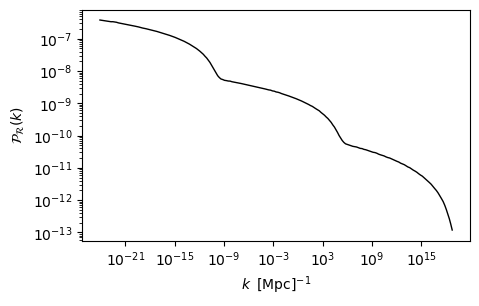

In [26]:
plt.figure(figsize=(5, 3))
plt.loglog(df1['K']/ mpc, df1['P_R'],color='black',linewidth=1)
plt.xlabel(r'$k\;\;[\mathrm{Mpc}]^{-1}$',fontweight='bold')
plt.ylabel(r'$\mathcal{P}_\mathcal{R}(k)$',fontweight='bold')
plt.savefig('3F_power_triple.pdf',format = 'pdf' ,  bbox_inches="tight", dpi = 600)
plt.show()